<a href="https://colab.research.google.com/github/OJB-Quantum/Notebooks-for-Ideas/blob/main/Waveform_Generator_Flowchart_in_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Authored by Onri Jay Benally (2026)

Open Access (CC-BY-4.0)

Using Python 3.12.13 environment at: /usr
Checked 1 package in 90ms


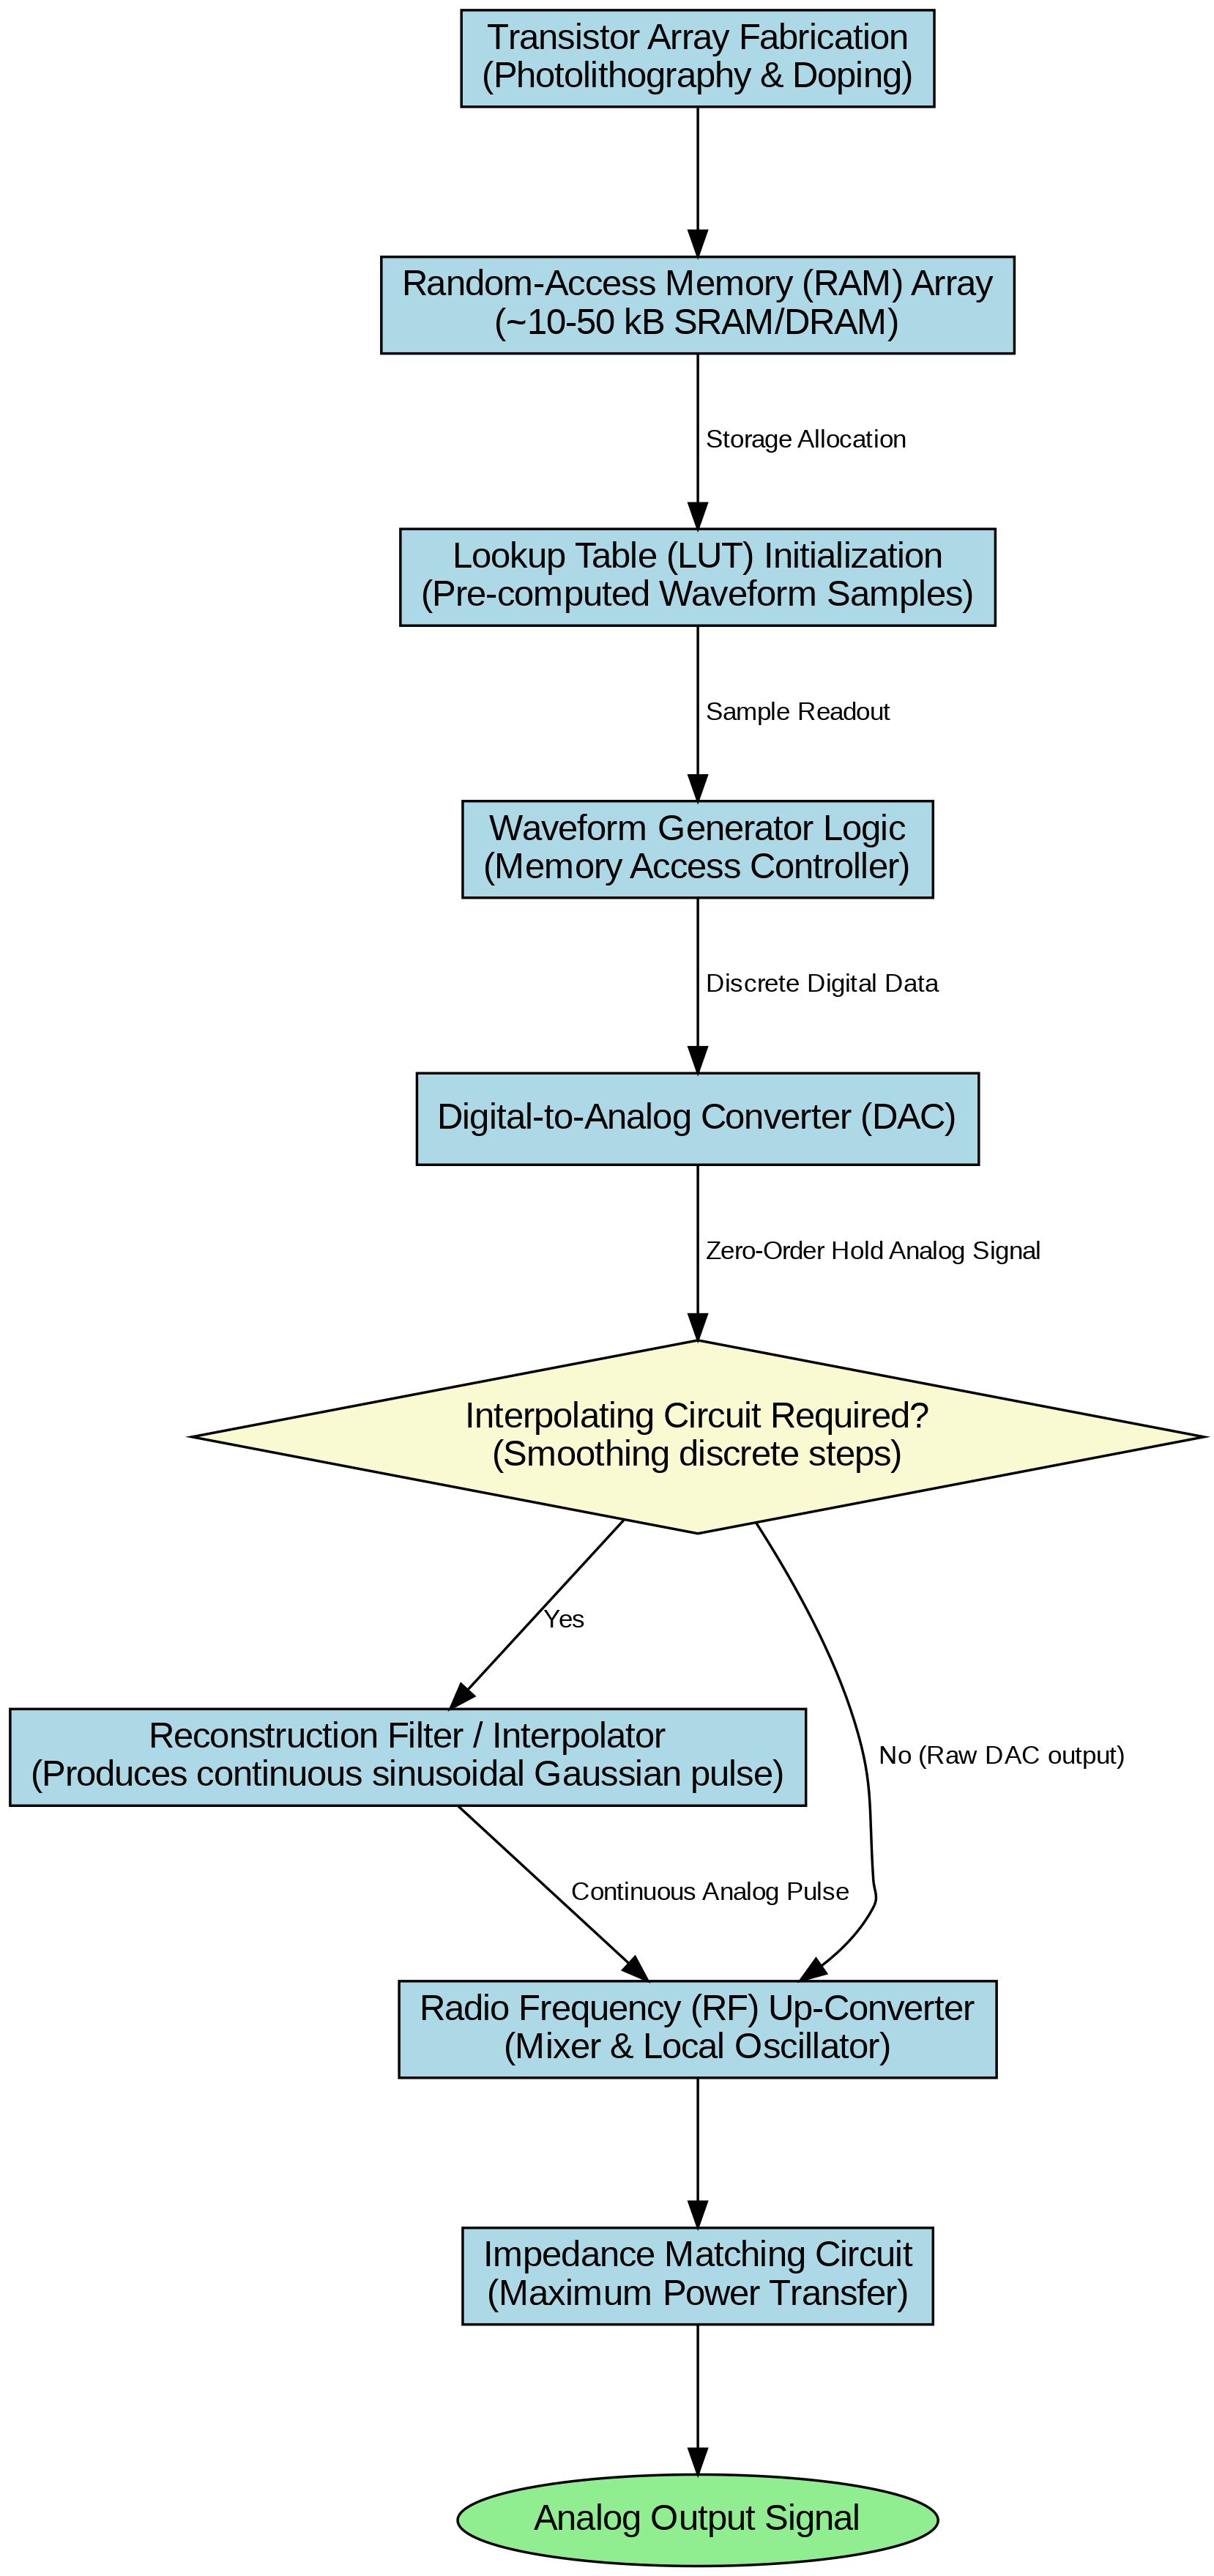

In [7]:
!uv pip install graphviz

import os
from IPython.display import Image, display

# Control knobs for visual rendering parameters
DPI = 250
OUTPUT_FILENAME = 'waveform_generator_flowchart'

# Graphviz DOT language specification
dot_content = f"""
digraph G {{
    graph [dpi={DPI}, fontname="Helvetica", nodesep=0.5, ranksep=0.8];
    node [shape=box, fontname="Helvetica", style=filled, fillcolor=lightblue];
    edge [fontname="Helvetica", fontsize=10];

    T_ARRAY [label="Transistor Array Fabrication\\n(Photolithography & Doping)"];
    RAM [label="Random-Access Memory (RAM) Array\\n(~10-50 kB SRAM/DRAM)"];
    LUT_INIT [label="Lookup Table (LUT) Initialization\\n(Pre-computed Waveform Samples)"];
    WAV_GEN [label="Waveform Generator Logic\\n(Memory Access Controller)"];
    DAC [label="Digital-to-Analog Converter (DAC)"];
    INTERP [shape=diamond, fillcolor=lightgoldenrodyellow, label="Interpolating Circuit Required?\\n(Smoothing discrete steps)"];
    RECON_FILTER [label="Reconstruction Filter / Interpolator\\n(Produces continuous sinusoidal Gaussian pulse)"];
    UPCONV [label="Radio Frequency (RF) Up-Converter\\n(Mixer & Local Oscillator)"];
    IMP_MATCH [label="Impedance Matching Circuit\\n(Maximum Power Transfer)"];
    OUTPUT [shape=ellipse, fillcolor=lightgreen, label="Analog Output Signal"];

    T_ARRAY -> RAM;
    RAM -> LUT_INIT [label=" Storage Allocation"];
    LUT_INIT -> WAV_GEN [label=" Sample Readout"];
    WAV_GEN -> DAC [label=" Discrete Digital Data"];
    DAC -> INTERP [label=" Zero-Order Hold Analog Signal"];
    INTERP -> RECON_FILTER [label=" Yes"];
    INTERP -> UPCONV [label=" No (Raw DAC output)"];
    RECON_FILTER -> UPCONV [label=" Continuous Analog Pulse"];
    UPCONV -> IMP_MATCH;
    IMP_MATCH -> OUTPUT;
}}
"""

# Write the dot specification to a temporary file
with open(f"{OUTPUT_FILENAME}.dot", "w") as dot_file:
    dot_file.write(dot_content)

# Execute the system Graphviz command to generate the high-resolution PNG image
os.system(f"dot -Tpng -Gdpi={DPI} {OUTPUT_FILENAME}.dot -o {OUTPUT_FILENAME}.png")

# Display the generated flowchart inline seamlessly
display(Image(filename=f"{OUTPUT_FILENAME}.png"))

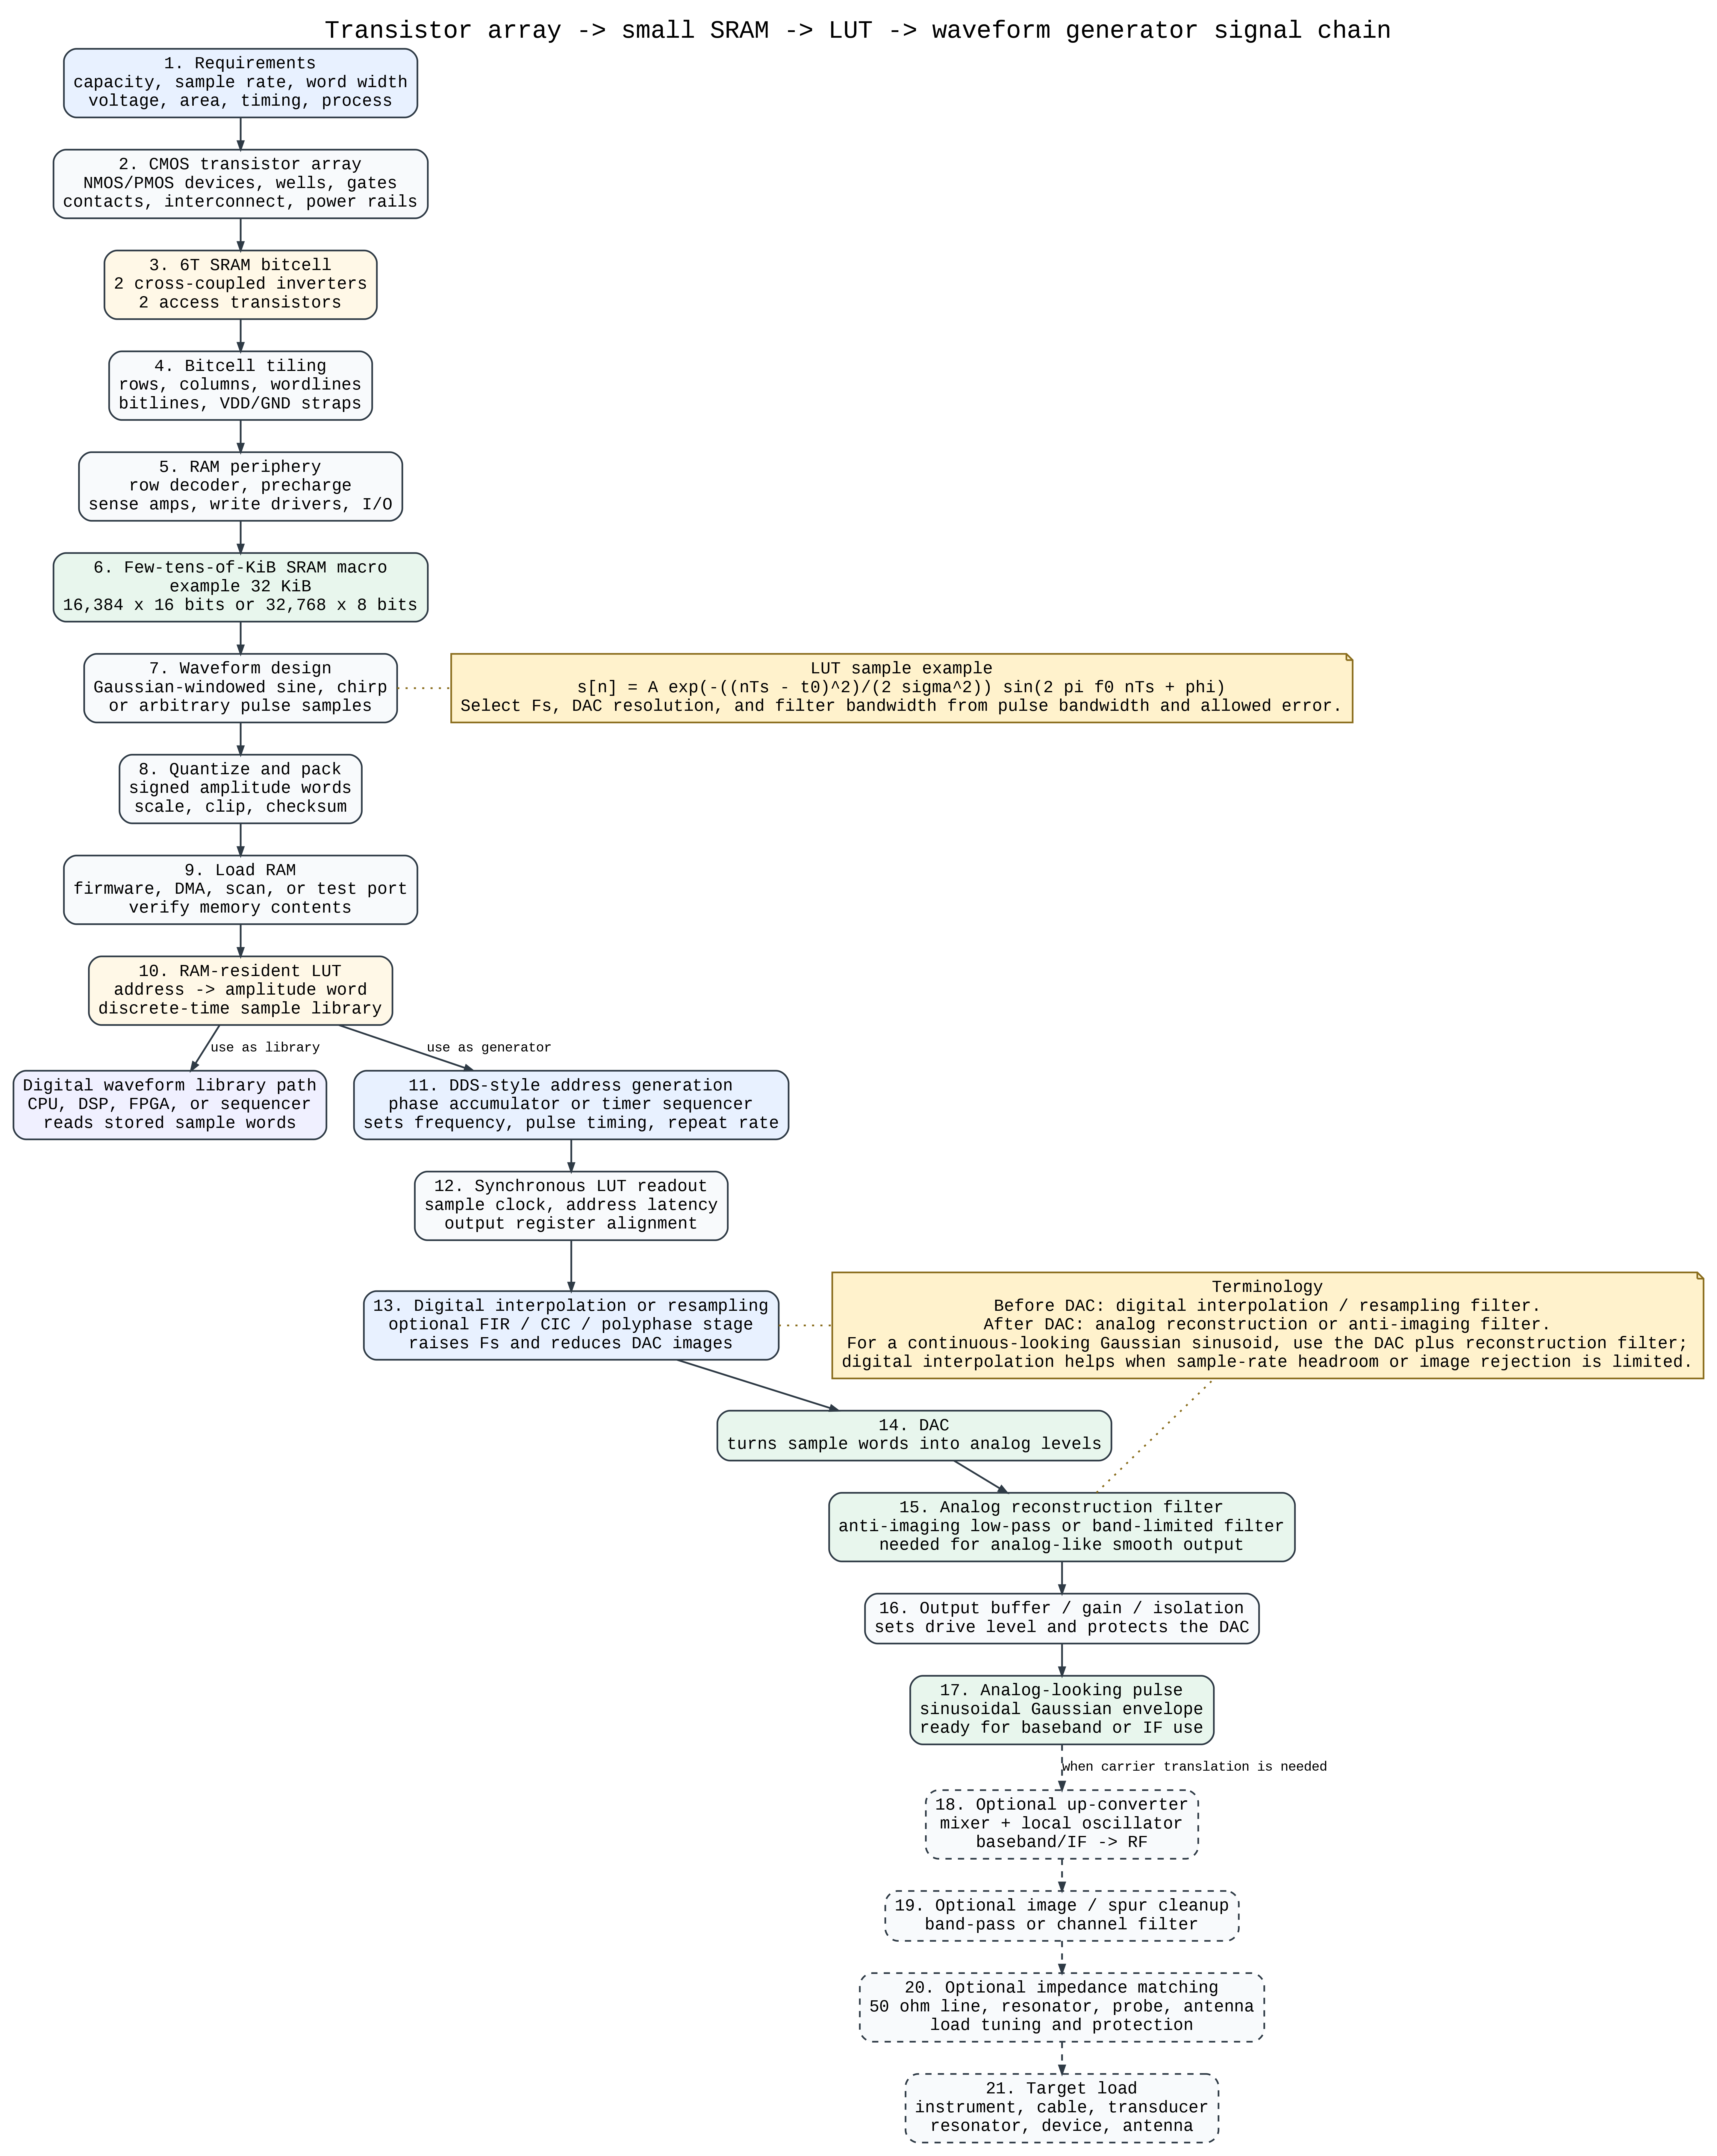

PNG: /content/transistor_ram_lut_waveform_flowchart_250dpi.png
SVG: /content/transistor_ram_lut_waveform_flowchart.svg
DOT: /content/transistor_ram_lut_waveform_flowchart.dot


In [6]:
"""Generate a 250 DPI Graphviz flowchart for SRAM LUT waveform generation."""

from __future__ import annotations

import shutil
import subprocess
import sys
from pathlib import Path

from IPython.display import Image, display


# ---------------------------------------------------------------------------
# Control knobs
# ---------------------------------------------------------------------------

OUTPUT_STEM = "transistor_ram_lut_waveform_flowchart"
OUTPUT_DIR = Path("/content")
DPI = 250

GRAPH_TITLE = (
    "Transistor array -> small SRAM -> LUT -> waveform generator signal chain"
)

PNG_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}_{DPI}dpi.png"
SVG_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}.svg"
DOT_PATH = OUTPUT_DIR / f"{OUTPUT_STEM}.dot"


# ---------------------------------------------------------------------------
# Dependency setup for Google Colab
# ---------------------------------------------------------------------------

def run_command(command: list[str]) -> None:
    """Run a shell command and raise a clear error on failure."""
    completed = subprocess.run(
        command,
        check=False,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )

    if completed.returncode != 0:
        joined = " ".join(command)
        raise RuntimeError(
            f"Command failed: {joined}\n\n{completed.stdout}"
        )


def ensure_colab_graphviz() -> None:
    """Install Graphviz system binaries and the Python Graphviz package."""
    if shutil.which("dot") is None:
        run_command(["apt-get", "update", "-qq"])
        run_command(["apt-get", "install", "-y", "graphviz"])

    run_command([sys.executable, "-m", "pip", "install", "-q", "uv"])
    run_command(["uv", "pip", "install", "--system", "-q", "graphviz"])


ensure_colab_graphviz()

import graphviz  # noqa: E402


# ---------------------------------------------------------------------------
# Graph construction
# ---------------------------------------------------------------------------

def add_process_node(
    graph: graphviz.Digraph,
    node_id: str,
    label: str,
    fillcolor: str = "#f8fafc",
    style: str = "rounded,filled",
    shape: str = "rect",
) -> None:
    """Add one labeled process node to the graph."""
    graph.node(
        node_id,
        label=label,
        fillcolor=fillcolor,
        style=style,
        shape=shape,
    )


def build_flowchart() -> graphviz.Digraph:
    """Build the SRAM LUT waveform generator flowchart."""
    graph = graphviz.Digraph(
        name="TransistorRamLutWaveform",
        format="png",
        engine="dot",
    )

    graph.attr(
        "graph",
        dpi=str(DPI),
        rankdir="TB",
        splines="spline",
        overlap="false",
        pad="0.18",
        nodesep="0.36",
        ranksep="0.42",
        bgcolor="white",
        fontname="DejaVu Sans",
        fontsize="24",
        labelloc="t",
        label=GRAPH_TITLE,
    )

    graph.attr(
        "node",
        shape="rect",
        style="rounded,filled",
        penwidth="1.6",
        color="#2f3b46",
        fillcolor="#f8fafc",
        fontname="DejaVu Sans",
        fontsize="16",
        margin="0.12,0.08",
    )

    graph.attr(
        "edge",
        color="#2f3b46",
        penwidth="1.7",
        arrowsize="0.8",
        fontname="DejaVu Sans",
        fontsize="13",
    )

    add_process_node(
        graph,
        "req",
        (
            "1. Requirements\n"
            "capacity, sample rate, word width\n"
            "voltage, area, timing, process"
        ),
        fillcolor="#e8f1ff",
    )
    add_process_node(
        graph,
        "mos",
        (
            "2. CMOS transistor array\n"
            "NMOS/PMOS devices, wells, gates\n"
            "contacts, interconnect, power rails"
        ),
    )
    add_process_node(
        graph,
        "bitcell",
        (
            "3. 6T SRAM bitcell\n"
            "2 cross-coupled inverters\n"
            "2 access transistors"
        ),
        fillcolor="#fff8e7",
    )
    add_process_node(
        graph,
        "array",
        (
            "4. Bitcell tiling\n"
            "rows, columns, wordlines\n"
            "bitlines, VDD/GND straps"
        ),
    )
    add_process_node(
        graph,
        "periphery",
        (
            "5. RAM periphery\n"
            "row decoder, precharge\n"
            "sense amps, write drivers, I/O"
        ),
    )
    add_process_node(
        graph,
        "ram",
        (
            "6. Few-tens-of-KiB SRAM macro\n"
            "example 32 KiB\n"
            "16,384 x 16 bits or 32,768 x 8 bits"
        ),
        fillcolor="#e8f6ed",
    )
    add_process_node(
        graph,
        "sample_gen",
        (
            "7. Waveform design\n"
            "Gaussian-windowed sine, chirp\n"
            "or arbitrary pulse samples"
        ),
    )
    add_process_node(
        graph,
        "quant",
        (
            "8. Quantize and pack\n"
            "signed amplitude words\n"
            "scale, clip, checksum"
        ),
    )
    add_process_node(
        graph,
        "load",
        (
            "9. Load RAM\n"
            "firmware, DMA, scan, or test port\n"
            "verify memory contents"
        ),
    )
    add_process_node(
        graph,
        "lut",
        (
            "10. RAM-resident LUT\n"
            "address -> amplitude word\n"
            "discrete-time sample library"
        ),
        fillcolor="#fff8e7",
    )

    add_process_node(
        graph,
        "library",
        (
            "Digital waveform library path\n"
            "CPU, DSP, FPGA, or sequencer\n"
            "reads stored sample words"
        ),
        fillcolor="#f0f0ff",
    )

    add_process_node(
        graph,
        "phase",
        (
            "11. DDS-style address generation\n"
            "phase accumulator or timer sequencer\n"
            "sets frequency, pulse timing, repeat rate"
        ),
        fillcolor="#e8f1ff",
    )
    add_process_node(
        graph,
        "readout",
        (
            "12. Synchronous LUT readout\n"
            "sample clock, address latency\n"
            "output register alignment"
        ),
    )
    add_process_node(
        graph,
        "interp",
        (
            "13. Digital interpolation or resampling\n"
            "optional FIR / CIC / polyphase stage\n"
            "raises Fs and reduces DAC images"
        ),
        fillcolor="#e8f1ff",
    )
    add_process_node(
        graph,
        "dac",
        "14. DAC\nturns sample words into analog levels",
        fillcolor="#e8f6ed",
    )
    add_process_node(
        graph,
        "recon",
        (
            "15. Analog reconstruction filter\n"
            "anti-imaging low-pass or band-limited filter\n"
            "needed for analog-like smooth output"
        ),
        fillcolor="#e8f6ed",
    )
    add_process_node(
        graph,
        "buffer",
        (
            "16. Output buffer / gain / isolation\n"
            "sets drive level and protects the DAC"
        ),
    )
    add_process_node(
        graph,
        "analog",
        (
            "17. Analog-looking pulse\n"
            "sinusoidal Gaussian envelope\n"
            "ready for baseband or IF use"
        ),
        fillcolor="#e8f6ed",
    )

    optional_style = "rounded,filled,dashed"
    add_process_node(
        graph,
        "upconv",
        (
            "18. Optional up-converter\n"
            "mixer + local oscillator\n"
            "baseband/IF -> RF"
        ),
        style=optional_style,
    )
    add_process_node(
        graph,
        "bpf",
        (
            "19. Optional image / spur cleanup\n"
            "band-pass or channel filter"
        ),
        style=optional_style,
    )
    add_process_node(
        graph,
        "match",
        (
            "20. Optional impedance matching\n"
            "50 ohm line, resonator, probe, antenna\n"
            "load tuning and protection"
        ),
        style=optional_style,
    )
    add_process_node(
        graph,
        "loadnode",
        (
            "21. Target load\n"
            "instrument, cable, transducer\n"
            "resonator, device, antenna"
        ),
        style=optional_style,
    )

    graph.node(
        "terminology",
        shape="note",
        fillcolor="#fff2cc",
        color="#8a6d1d",
        label=(
            "Terminology\n"
            "Before DAC: digital interpolation / resampling filter.\n"
            "After DAC: analog reconstruction or anti-imaging filter.\n"
            "For a continuous-looking Gaussian sinusoid, use the DAC plus "
            "reconstruction filter;\n"
            "digital interpolation helps when sample-rate headroom or image "
            "rejection is limited."
        ),
    )

    graph.node(
        "formula",
        shape="note",
        fillcolor="#fff2cc",
        color="#8a6d1d",
        label=(
            "LUT sample example\n"
            "s[n] = A exp(-((nTs - t0)^2)/(2 sigma^2)) "
            "sin(2 pi f0 nTs + phi)\n"
            "Select Fs, DAC resolution, and filter bandwidth from pulse "
            "bandwidth and allowed error."
        ),
    )

    main_chain = [
        "req",
        "mos",
        "bitcell",
        "array",
        "periphery",
        "ram",
        "sample_gen",
        "quant",
        "load",
        "lut",
    ]

    for source, target in zip(main_chain[:-1], main_chain[1:]):
        graph.edge(source, target)

    graph.edge("lut", "library", label="use as library")
    graph.edge("lut", "phase", label="use as generator")

    generator_chain = [
        "phase",
        "readout",
        "interp",
        "dac",
        "recon",
        "buffer",
        "analog",
    ]

    for source, target in zip(generator_chain[:-1], generator_chain[1:]):
        graph.edge(source, target)

    graph.edge(
        "analog",
        "upconv",
        style="dashed",
        label="when carrier translation is needed",
    )
    graph.edge("upconv", "bpf", style="dashed")
    graph.edge("bpf", "match", style="dashed")
    graph.edge("match", "loadnode", style="dashed")

    graph.edge(
        "sample_gen",
        "formula",
        style="dotted",
        arrowhead="none",
        color="#8a6d1d",
    )
    graph.edge(
        "interp",
        "terminology",
        style="dotted",
        arrowhead="none",
        color="#8a6d1d",
    )
    graph.edge(
        "recon",
        "terminology",
        style="dotted",
        arrowhead="none",
        color="#8a6d1d",
    )

    with graph.subgraph() as same_rank:
        same_rank.attr(rank="same")
        same_rank.node("library")
        same_rank.node("phase")

    with graph.subgraph() as same_rank:
        same_rank.attr(rank="same")
        same_rank.node("interp")
        same_rank.node("terminology")

    with graph.subgraph() as same_rank:
        same_rank.attr(rank="same")
        same_rank.node("sample_gen")
        same_rank.node("formula")

    return graph


# ---------------------------------------------------------------------------
# Render outputs
# ---------------------------------------------------------------------------

flowchart = build_flowchart()

DOT_PATH.write_text(flowchart.source, encoding="utf-8")

rendered_png = Path(
    flowchart.render(
        filename=str(OUTPUT_DIR / f"{OUTPUT_STEM}_{DPI}dpi"),
        format="png",
        cleanup=True,
    )
)
rendered_png.rename(PNG_PATH)

svg_graph = graphviz.Source(flowchart.source, format="svg", engine="dot")
rendered_svg = Path(
    svg_graph.render(
        filename=str(OUTPUT_DIR / OUTPUT_STEM),
        cleanup=True,
    )
)
rendered_svg.rename(SVG_PATH)

display(Image(filename=str(PNG_PATH)))

print(f"PNG: {PNG_PATH}")
print(f"SVG: {SVG_PATH}")
print(f"DOT: {DOT_PATH}")